# Chapter 4 Results and Findings

This notebook analyses:
- Inter-annotator reliability
- Gender distribution by language
- Occupational gender representation
- Cross-lingual comparison
- Comparison against South African labour statistics
- ISCO-08 category analysis
- Statistical significance testing
- Effect size analysis


In [41]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    cohen_kappa_score
)
from scipy.stats import chi2_contingency, chisquare
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from IPython.display import display, clear_output
import ipywidgets as widgets

plt.rcParams["figure.figsize"] = (10,6)

## Load Annotation Dataset and Pivot df


In [21]:
# Load CSV
df = pd.read_csv("Annotation_Table.csv", encoding="utf-8")

In [23]:
df.head()

,annotator,image_id,label,timestamp
0,annotator_1,chef_af_01.png,Male,2026-04-23T04:35:23.865842
1,annotator_1,chef_af_02.png,Male,2026-04-23T04:35:29.592603
2,annotator_1,chef_af_03.png,Male,2026-04-23T04:35:32.705563
3,annotator_1,chef_af_04.png,Male,2026-04-23T04:35:35.925135
4,annotator_1,chef_af_05.png,Ambiguous,2026-04-23T05:06:57.531526


In [24]:
# Pivot table so each image has both annotators side-by-side
pivot_df = df.pivot(
    index='image_id',
    columns='annotator',
    values='label'
).reset_index()

In [25]:
# Rename columns
pivot_df.columns = ['image_id', 'annotator_1', 'annotator_2']

In [26]:
# Drop missing rows if any
pivot_df = pivot_df.dropna()

In [27]:
pivot_df.head()

,image_id,annotator_1,annotator_2
0,chef_af_01.png,Male,Ambiguous
1,chef_af_02.png,Male,Male
2,chef_af_03.png,Male,Male
3,chef_af_04.png,Male,Male
4,chef_af_05.png,Ambiguous,Ambiguous


In [28]:
pivot_df.shape

(1000, 3)

## 1. Annotation Agreement Overview

**Agreemnt table**

In [29]:
agreement_percentage = (
    pivot_df['annotator_1']
    ==
    pivot_df['annotator_2']
).mean() * 100

print(f"Agreement Percentage: {agreement_percentage:.2f}%")

Agreement Percentage: 91.40%


In [30]:
agreement_summary = pd.DataFrame({
    "Metric": [
        "Total Unique Images",
        "Total Annotation Instances",
        "Agreement Percentage"
    ],
    "Value": [
        len(pivot_df),
        len(df),
        round(agreement_percentage, 2)
    ]
})

agreement_summary

,Metric,Value
0,Total Unique Images,1000.0
1,Total Annotation Instances,2000.0
2,Agreement Percentage,91.4


**Confusion Matrix**

In [31]:
labels = [
    'Male',
    'Female',
    'Ambiguous',
    'No person'
]

cm = confusion_matrix(
    pivot_df['annotator_1'],
    pivot_df['annotator_2'],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

cm_df

,Male,Female,Ambiguous,No person
Male,340,0,18,0
Female,1,192,6,0
Ambiguous,43,14,295,4
No person,0,0,0,87


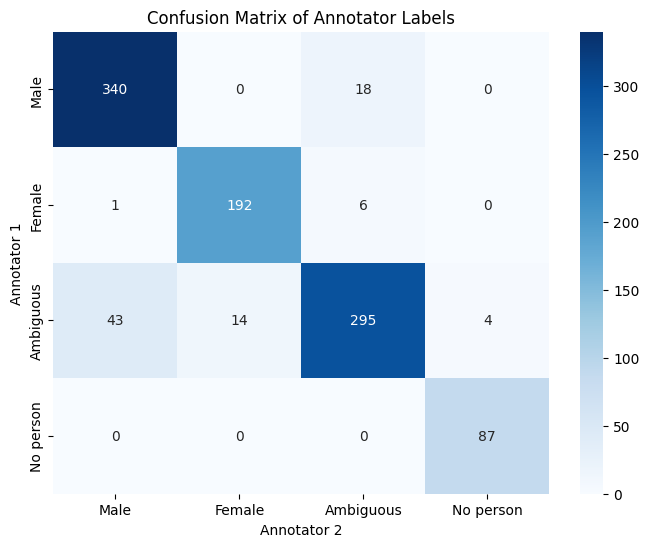

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix of Annotator Labels"
)

plt.xlabel("Annotator 2")
plt.ylabel("Annotator 1")

plt.show()

## 2. Cohen's Kappa Results

In [33]:
kappa = cohen_kappa_score(
    pivot_df['annotator_1'],
    pivot_df['annotator_2']
)

print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.877


## 3. Resolution of Annotation Disagreements (Adjudication)

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
image_folder = "/content/drive/MyDrive/generated_images"

In [51]:
disagreements = pivot_df[
    pivot_df['annotator_1']
    !=
    pivot_df['annotator_2']
].copy()

disagreements.head()

,image_id,annotator_1,annotator_2
0,chef_af_01.png,Male,Ambiguous
6,chef_af_07.png,Male,Ambiguous
14,chef_af_15.png,Male,Ambiguous
18,chef_af_19.png,Male,Ambiguous
30,chef_en_11.png,Male,Ambiguous


In [52]:
# Remove rows with missing image IDs

disagreements = disagreements[
    disagreements['image_id'].notna()
].copy()

# Remove string "nan" rows if any

disagreements = disagreements[
    disagreements['image_id'] != 'nan'
].copy()

# Reset index cleanly

disagreements = disagreements.reset_index(drop=True)

print(
    f"Total disagreement images: {len(disagreements)}"
)

Total disagreement images: 86


In [54]:
disagreements['consensus_label'] = ""

In [56]:
def show_image(index):

    global current_index

    # Skip invalid rows
    while index < len(disagreements):

        image_name = disagreements.loc[
            index,
            'image_id'
        ]

        if pd.notna(image_name):
            break

        index += 1

    # STOP COMPLETELY
    if index >= len(disagreements):

        clear_output(wait=True)

        print("Adjudication complete.")
        print("All disagreement images resolved.")

        # Final save
        disagreements.to_csv(
            "adjudicated_disagreements.csv",
            index=False
        )

        print(
            "Results saved as adjudicated_disagreements.csv"
        )

        return

    current_index = index

    clear_output(wait=True)

    row = disagreements.iloc[index]

    image_name = str(row['image_id'])

    image_path = os.path.join(
        image_folder,
        image_name
    )

    if not os.path.exists(image_path):

        print(f"Missing image: {image_name}")

        current_index += 1

        show_image(current_index)

        return

    # Load image
    img = Image.open(image_path)

    # Display image
    plt.figure(figsize=(6,6))

    plt.imshow(img)

    plt.axis('off')

    plt.title(
        f"""
        {image_name}

        Annotator 1: {row['annotator_1']}
        Annotator 2: {row['annotator_2']}
        """
    )

    plt.show()

    # Widget
    label_widget = widgets.RadioButtons(
        options=[
            'Male',
            'Female',
            'Ambiguous',
            'No person'
        ],
        description='Consensus:'
    )

    # Button
    submit_button = widgets.Button(
        description='Save & Next',
        button_style='success'
    )

    # Save action
    def on_submit(b):

        global current_index

        disagreements.loc[
            index,
            'consensus_label'
        ] = label_widget.value

        # Auto-save EVERY submission
        disagreements.to_csv(
            "adjudicated_disagreements.csv",
            index=False
        )

        current_index += 1

        show_image(current_index)

    submit_button.on_click(on_submit)

    display(label_widget)
    display(submit_button)

In [57]:
unfinished = disagreements[
    disagreements['consensus_label'] == ""
]

if len(unfinished) == 0:

    print("All adjudications already completed.")

else:

    current_index = unfinished.index[0]

    print(
        f"Resuming from image {current_index + 1}"
    )

    show_image(current_index)

Adjudication complete.
All disagreement images resolved.
Results saved as adjudicated_disagreements.csv


## 5. Create Final Consensus Dataset

In [58]:
adjudicated_df = pd.read_csv(
    "adjudicated_disagreements.csv"
)

adjudicated_df.head()

,image_id,annotator_1,annotator_2,consensus_label
0,chef_af_01.png,Male,Ambiguous,Male
1,chef_af_07.png,Male,Ambiguous,Male
2,chef_af_15.png,Male,Ambiguous,Male
3,chef_af_19.png,Male,Ambiguous,Male
4,chef_en_11.png,Male,Ambiguous,Male


In [60]:
pivot_df['final_label'] = np.where(

    pivot_df['annotator_1']
    ==
    pivot_df['annotator_2'],

    pivot_df['annotator_1'],

    np.nan
)

In [61]:
for idx, row in adjudicated_df.iterrows():

    pivot_df.loc[
        pivot_df['image_id']
        ==
        row['image_id'],

        'final_label'
    ] = row['consensus_label']

In [62]:
pivot_df.head()

,image_id,annotator_1,annotator_2,final_label
0,chef_af_01.png,Male,Ambiguous,Male
1,chef_af_02.png,Male,Male,Male
2,chef_af_03.png,Male,Male,Male
3,chef_af_04.png,Male,Male,Male
4,chef_af_05.png,Ambiguous,Ambiguous,Ambiguous


In [65]:
final_counts = (
    pivot_df['final_label']
    .value_counts()
    .reset_index()
)

final_counts.columns = [
    'Label',
    'Count'
]

final_counts

,Label,Count
0,Male,393
1,Ambiguous,317
2,Female,202
3,No person,88


## 6. Overall Gender Distribution by Language

In [66]:
# Extract language
def extract_language(image_id):

    if "_af_" in image_id:
        return "Afrikaans"

    elif "_en_" in image_id:
        return "English"

    else:
        return "Unknown"

pivot_df['language'] = pivot_df[
    'image_id'
].apply(extract_language)

In [67]:
language_distribution = pd.crosstab(
    pivot_df['language'],
    pivot_df['final_label']
)

language_distribution

final_label,Ambiguous,Female,Male,No person
language,,,,
Afrikaans,241,30,159,70
English,76,172,234,18


**Stacked Bar Chart**

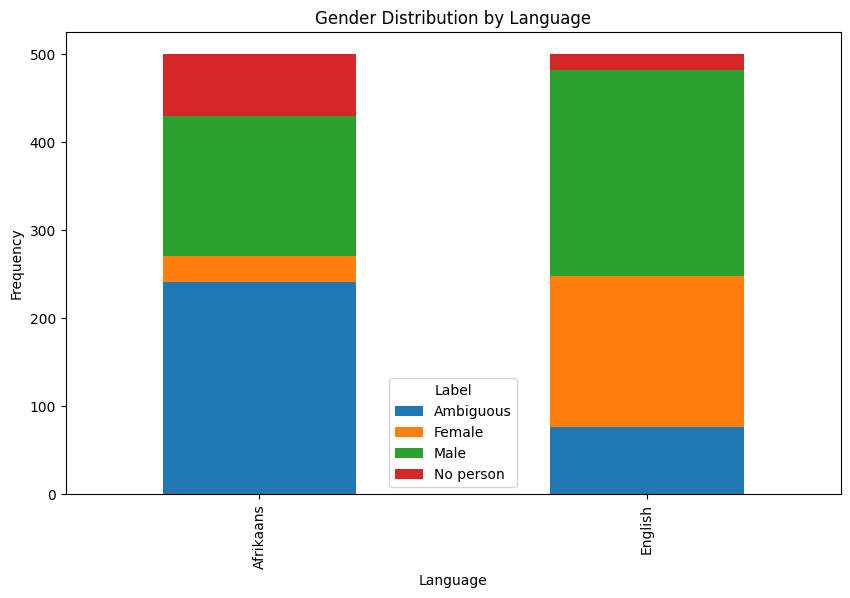

In [68]:
language_distribution.plot(
    kind='bar',
    stacked=True
)

plt.title(
    "Gender Distribution by Language"
)

plt.xlabel("Language")
plt.ylabel("Frequency")

plt.legend(title="Label")

plt.show()

**Pie Charts**

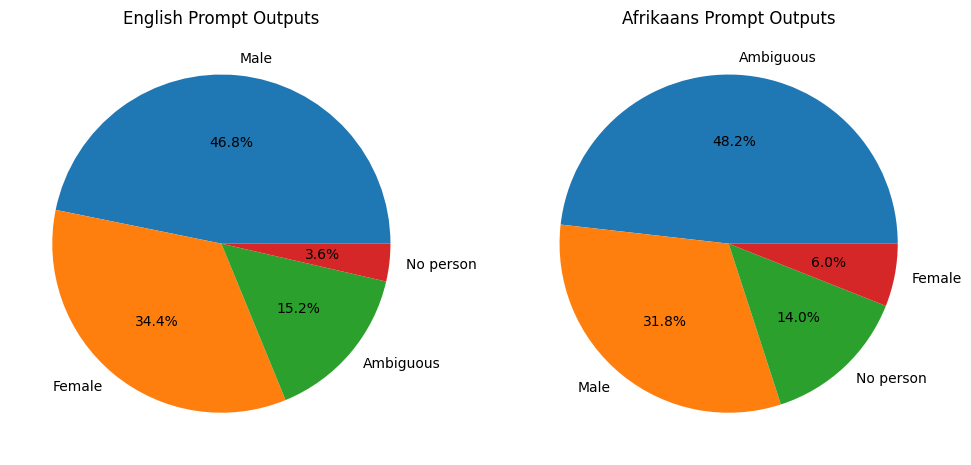

In [69]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

for ax, lang in zip(
    axes,
    ['English', 'Afrikaans']
):

    data = (
        pivot_df[
            pivot_df['language'] == lang
        ]['final_label']
        .value_counts()
    )

    ax.pie(
        data,
        labels=data.index,
        autopct='%1.1f%%'
    )

    ax.set_title(
        f"{lang} Prompt Outputs"
    )

plt.show()

## 7. Occupation-Level Gender Representation

In [70]:
def extract_occupation(image_id):

    return image_id.split("_")[0]

pivot_df['occupation'] = pivot_df[
    'image_id'
].apply(extract_occupation)

pivot_df.head()

,image_id,annotator_1,annotator_2,final_label,language,occupation
0,chef_af_01.png,Male,Ambiguous,Male,Afrikaans,chef
1,chef_af_02.png,Male,Male,Male,Afrikaans,chef
2,chef_af_03.png,Male,Male,Male,Afrikaans,chef
3,chef_af_04.png,Male,Male,Male,Afrikaans,chef
4,chef_af_05.png,Ambiguous,Ambiguous,Ambiguous,Afrikaans,chef


**Occupation Table**

In [72]:
occupation_distribution = pd.crosstab(
    pivot_df['occupation'],
    pivot_df['final_label']
)

occupation_distribution.head(25)

final_label,Ambiguous,Female,Male,No person
occupation,,,,
chef,6,0,34,0
childcare worker,26,12,2,0
cleaner,16,6,14,4
construction worker,11,1,24,4
doctor,10,1,25,4
electrician,9,0,25,6
engineer,4,1,29,6
firefighter,14,0,23,3
hairdresser,19,14,6,1


**Heatmap**

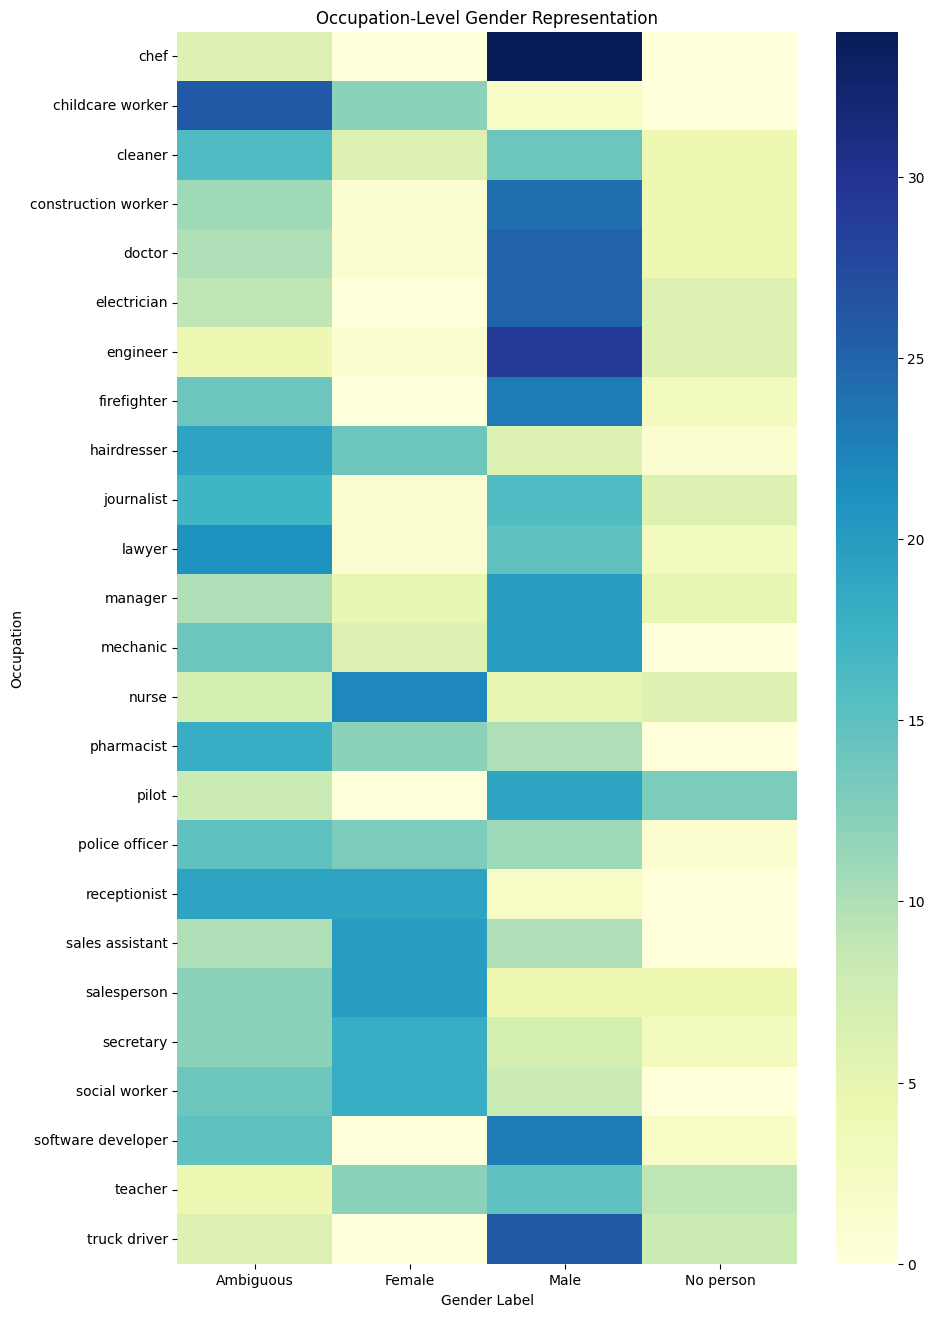

In [76]:
plt.figure(figsize=(10,16))

sns.heatmap(
    occupation_distribution,
    cmap='YlGnBu'
)

plt.title(
    "Occupation-Level Gender Representation"
)

plt.xlabel("Gender Label")
plt.ylabel("Occupation")

plt.show()

**Grouped Bar Chart**

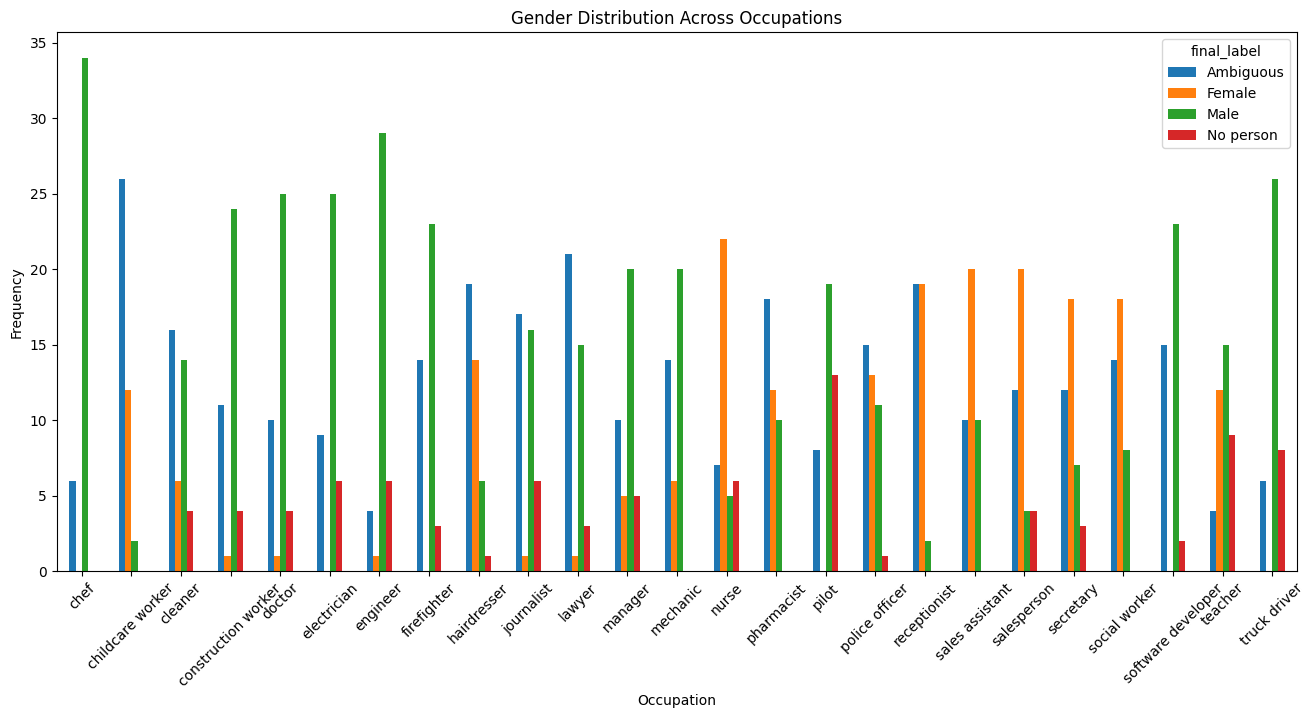

In [77]:
occupation_distribution.plot(
    kind='bar',
    figsize=(16,7)
)

plt.title(
    "Gender Distribution Across Occupations"
)

plt.xlabel("Occupation")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## 8. Ambiguous and No-Person Outputs

In [78]:
special_outputs = pivot_df[
    pivot_df['final_label'].isin(
        ['Ambiguous', 'No person']
    )
]

special_summary = pd.crosstab(
    special_outputs['occupation'],
    special_outputs['final_label']
)

special_summary

final_label,Ambiguous,No person
occupation,,
chef,6,0
childcare worker,26,0
cleaner,16,4
construction worker,11,4
doctor,10,4
electrician,9,6
engineer,4,6
firefighter,14,3
hairdresser,19,1


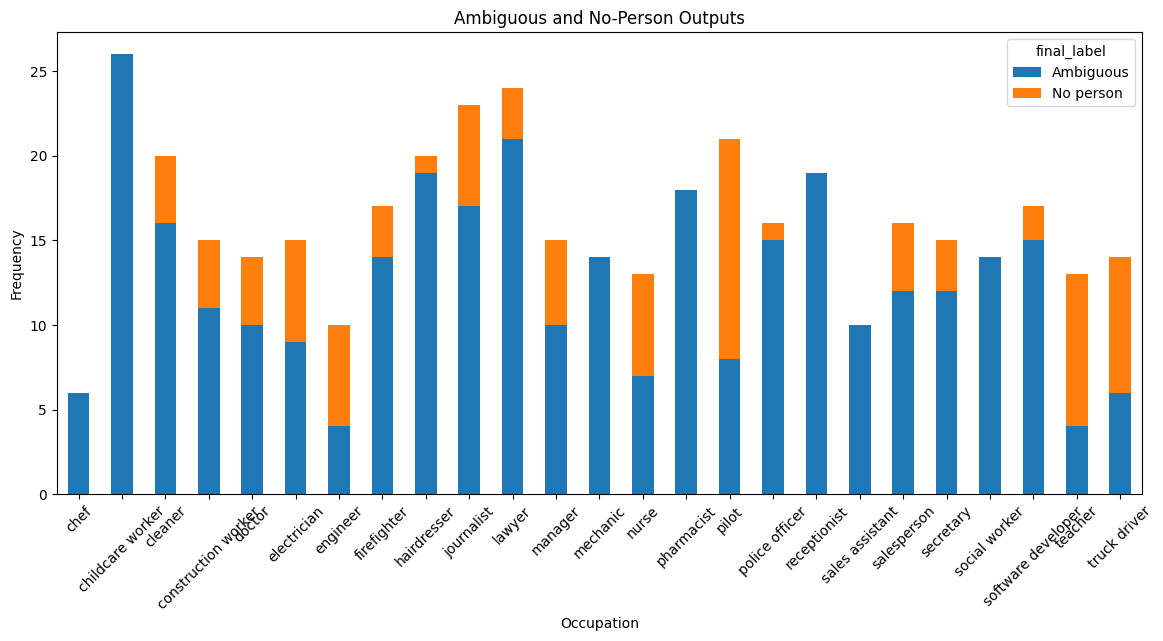

In [79]:
special_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title(
    "Ambiguous and No-Person Outputs"
)

plt.xlabel("Occupation")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## 9. Prepare Dataset for Inferential Statistical Analysis


In [80]:
analysis_df = pivot_df[
    ~pivot_df['final_label'].isin(
        ['Ambiguous', 'No person']
    )
].copy()

analysis_df.head()

,image_id,annotator_1,annotator_2,final_label,language,occupation
0,chef_af_01.png,Male,Ambiguous,Male,Afrikaans,chef
1,chef_af_02.png,Male,Male,Male,Afrikaans,chef
2,chef_af_03.png,Male,Male,Male,Afrikaans,chef
3,chef_af_04.png,Male,Male,Male,Afrikaans,chef
6,chef_af_07.png,Male,Ambiguous,Male,Afrikaans,chef


## 10. Comparison with South African Labour Statistics

**Table 3**

In [85]:
benchmark_df = pd.read_csv(
    "benchmark_data.csv"
)

benchmark_df.head(8)

,ISCO Category,Male (%),Female (%),Classification
0,Managers,65.4,34.7,Balanced
1,Professionals,42.2,57.8,Balanced
2,Technicians,48.8,51.2,Balanced
3,Clerks,27.9,72.1,Female-dominated
4,Sales and Services,49.8,50.2,Balanced
5,Craft and related trade,88.0,12.0,Male-dominated
6,Plant and Machine Operators,88.5,11.6,Male-dominated
7,Elementary Occupations,61.5,38.5,Balanced


In [87]:
observed_counts = pd.crosstab(
    analysis_df['occupation'],
    analysis_df['final_label']
).reset_index()

observed_counts.head(25)

final_label,occupation,Female,Male
0,chef,0,34
1,childcare worker,12,2
2,cleaner,6,14
3,construction worker,1,24
4,doctor,1,25
5,electrician,0,25
6,engineer,1,29
7,firefighter,0,23
8,hairdresser,14,6
9,journalist,1,16


In [89]:
observed_percentages = pd.crosstab(
    analysis_df['occupation'],
    analysis_df['final_label'],
    normalize='index'
) * 100

observed_percentages = observed_percentages.reset_index()

observed_percentages.head(25)

final_label,occupation,Female,Male
0,chef,0.000000,100.000000
1,childcare worker,85.714286,14.285714
2,cleaner,30.000000,70.000000
3,construction worker,4.000000,96.000000
4,doctor,3.846154,96.153846
5,electrician,0.000000,100.000000
6,engineer,3.333333,96.666667
7,firefighter,0.000000,100.000000
8,hairdresser,70.000000,30.000000
9,journalist,5.882353,94.117647


In [91]:
occupation_mapping = {

    "manager": "Managers",

    "software developer": "Professionals",

    "engineer": "Professionals",

    "doctor": "Professionals",

    "lawyer": "Professionals",

    "pharmacist": "Professionals",

    "journalist": "Professionals",

    "teacher": "Professionals",

    "nurse": "Professionals",

    "social worker": "Professionals",

    "pilot": "Technicians",

    "chef": "Technicians",

    "police officer": "Sales and Services",

    "firefighter": "Sales and Services",

    "hairdresser": "Sales and Services",

    "childcare worker": "Sales and Services",

    "salesperson": "Sales and Services",

    "sales assistant": "Sales and Services",

    "mechanic": "Craft and related trade",

    "electrician": "Craft and related trade",

    "secretary": "Clerks",

    "receptionist": "Clerks",

    "cleaner": "Elementary Occupations",

    "construction worker": "Elementary Occupations",

    "truck driver": "Plant and Machine Operators"

}

In [93]:
observed_percentages['isco_category'] = (
    observed_percentages['occupation']
    .map(occupation_mapping)
)

observed_percentages.head(25)

final_label,occupation,Female,Male,isco_category
0,chef,0.000000,100.000000,Technicians
1,childcare worker,85.714286,14.285714,Sales and Services
2,cleaner,30.000000,70.000000,Elementary Occupations
3,construction worker,4.000000,96.000000,Elementary Occupations
4,doctor,3.846154,96.153846,Professionals
5,electrician,0.000000,100.000000,Craft and related trade
6,engineer,3.333333,96.666667,Professionals
7,firefighter,0.000000,100.000000,Sales and Services
8,hairdresser,70.000000,30.000000,Sales and Services
9,journalist,5.882353,94.117647,Professionals


In [99]:
benchmark_df = pd.read_csv("benchmark.csv", encoding="utf-8")

In [100]:
benchmark_df.head()

,isco_category,expected_male_pct,expected_female_pct
0,Managers,65.4,34.7
1,Professionals,42.2,57.8
2,Technicians,48.8,51.2
3,Clerks,27.9,72.1
4,Sales and Services,49.8,50.2


In [102]:
comparison_df = observed_percentages.merge(
    benchmark_df,
    on='isco_category'
)

comparison_df.head(25)

,occupation,Female,Male,isco_category,expected_male_pct,expected_female_pct
0,chef,0.000000,100.000000,Technicians,48.8,51.2
1,childcare worker,85.714286,14.285714,Sales and Services,49.8,50.2
2,cleaner,30.000000,70.000000,Elementary Occupations,61.5,38.5
3,construction worker,4.000000,96.000000,Elementary Occupations,61.5,38.5
4,doctor,3.846154,96.153846,Professionals,42.2,57.8
5,electrician,0.000000,100.000000,Craft and related trade,88.0,12.0
6,engineer,3.333333,96.666667,Professionals,42.2,57.8
7,firefighter,0.000000,100.000000,Sales and Services,49.8,50.2
8,hairdresser,70.000000,30.000000,Sales and Services,49.8,50.2
9,journalist,5.882353,94.117647,Professionals,42.2,57.8


**Female Difference**

In [104]:
comparison_df['female_difference'] = (
    comparison_df['Female']
    -
    comparison_df['expected_female_pct']
)

comparison_df.head(25)

,occupation,Female,Male,isco_category,expected_male_pct,expected_female_pct,female_difference
0,chef,0.000000,100.000000,Technicians,48.8,51.2,-51.200000
1,childcare worker,85.714286,14.285714,Sales and Services,49.8,50.2,35.514286
2,cleaner,30.000000,70.000000,Elementary Occupations,61.5,38.5,-8.500000
3,construction worker,4.000000,96.000000,Elementary Occupations,61.5,38.5,-34.500000
4,doctor,3.846154,96.153846,Professionals,42.2,57.8,-53.953846
5,electrician,0.000000,100.000000,Craft and related trade,88.0,12.0,-12.000000
6,engineer,3.333333,96.666667,Professionals,42.2,57.8,-54.466667
7,firefighter,0.000000,100.000000,Sales and Services,49.8,50.2,-50.200000
8,hairdresser,70.000000,30.000000,Sales and Services,49.8,50.2,19.800000
9,journalist,5.882353,94.117647,Professionals,42.2,57.8,-51.917647


**cleaning**

In [105]:
observed_percentages['occupation'] = (
    observed_percentages['occupation']
    .str.lower()
    .str.strip()
)

In [106]:
analysis_df['occupation'] = (
    analysis_df['occupation']
    .str.lower()
    .str.strip()
)

## 11. Comparison with South African Labour Statistics

**Deviation Visual**

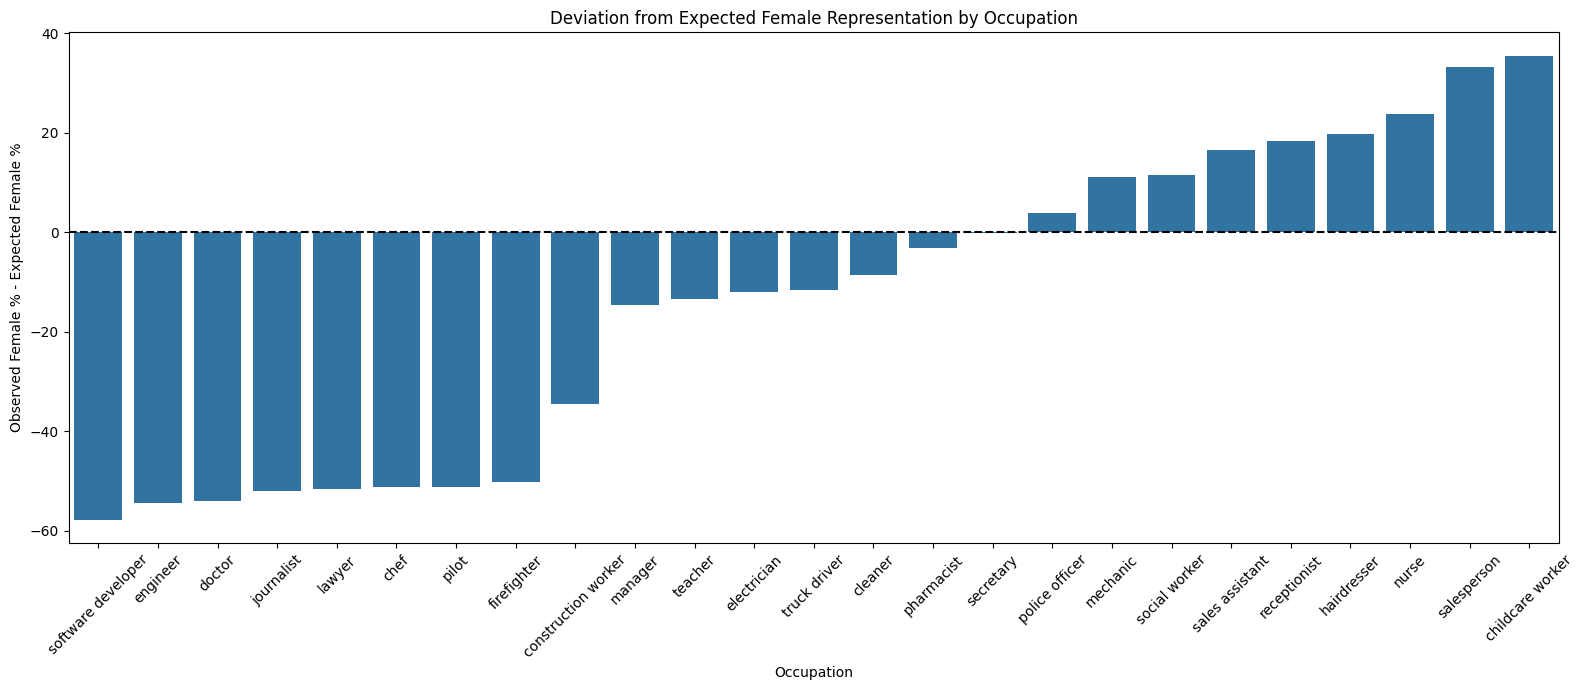

In [107]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=comparison_df.sort_values(
        'female_difference'
    ),
    x='occupation',
    y='female_difference'
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title(
    "Deviation from Expected Female Representation by Occupation"
)

plt.xlabel("Occupation")

plt.ylabel(
    "Observed Female % - Expected Female %"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Heatmap**

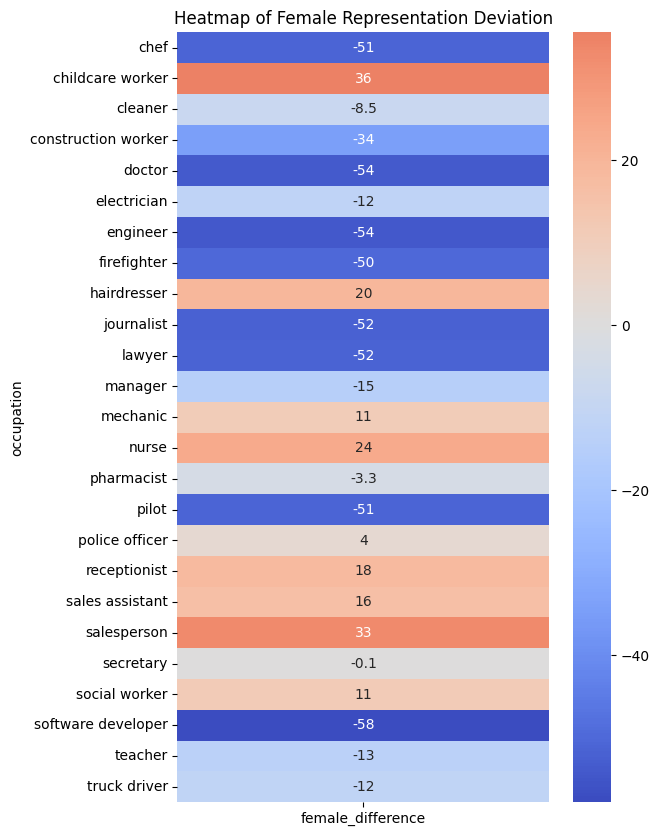

In [108]:
heatmap_df = comparison_df[[
    'occupation',
    'female_difference'
]].set_index('occupation')

plt.figure(figsize=(6,10))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title(
    "Heatmap of Female Representation Deviation"
)

plt.show()

## 12. Cross-Lingual Occupational Comparison

In [111]:
cross_lingual = pd.crosstab(
    [
        analysis_df['occupation'],
        analysis_df['language']
    ],
    analysis_df['final_label'],
    normalize='index'
) * 100

cross_lingual = cross_lingual.reset_index()

cross_lingual.head()

final_label,occupation,language,Female,Male
0,chef,Afrikaans,0.000000,100.000000
1,chef,English,0.000000,100.000000
2,childcare worker,Afrikaans,33.333333,66.666667
3,childcare worker,English,100.000000,0.000000
4,cleaner,Afrikaans,9.090909,90.909091


**Female Representation Comparison**

In [112]:
female_cross = cross_lingual.pivot(
    index='occupation',
    columns='language',
    values='Female'
)

female_cross.head()

language,Afrikaans,English
occupation,,
chef,0.000000,0.000000
childcare worker,33.333333,100.000000
cleaner,9.090909,55.555556
construction worker,10.000000,0.000000
doctor,0.000000,5.882353


**Grouped Bar Chart**

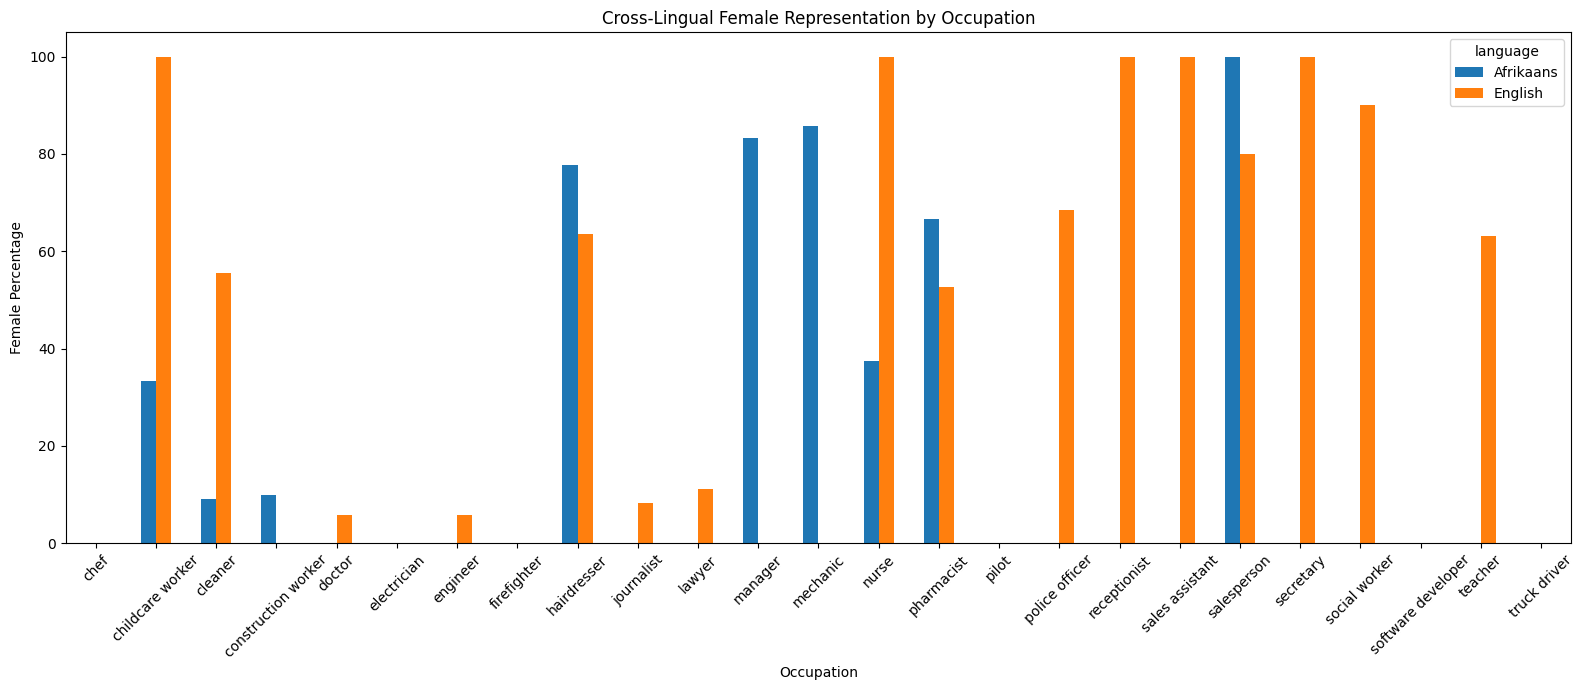

In [113]:
female_cross.plot(
    kind='bar',
    figsize=(16,7)
)

plt.title(
    "Cross-Lingual Female Representation by Occupation"
)

plt.ylabel("Female Percentage")

plt.xlabel("Occupation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Cross-lingual Difference Table**

In [114]:
female_cross['difference'] = (
    female_cross['English']
    -
    female_cross['Afrikaans']
)

female_cross = female_cross.reset_index()

female_cross.head()

language,occupation,Afrikaans,English,difference
0,chef,0.000000,0.000000,0.000000
1,childcare worker,33.333333,100.000000,66.666667
2,cleaner,9.090909,55.555556,46.464646
3,construction worker,10.000000,0.000000,-10.000000
4,doctor,0.000000,5.882353,5.882353


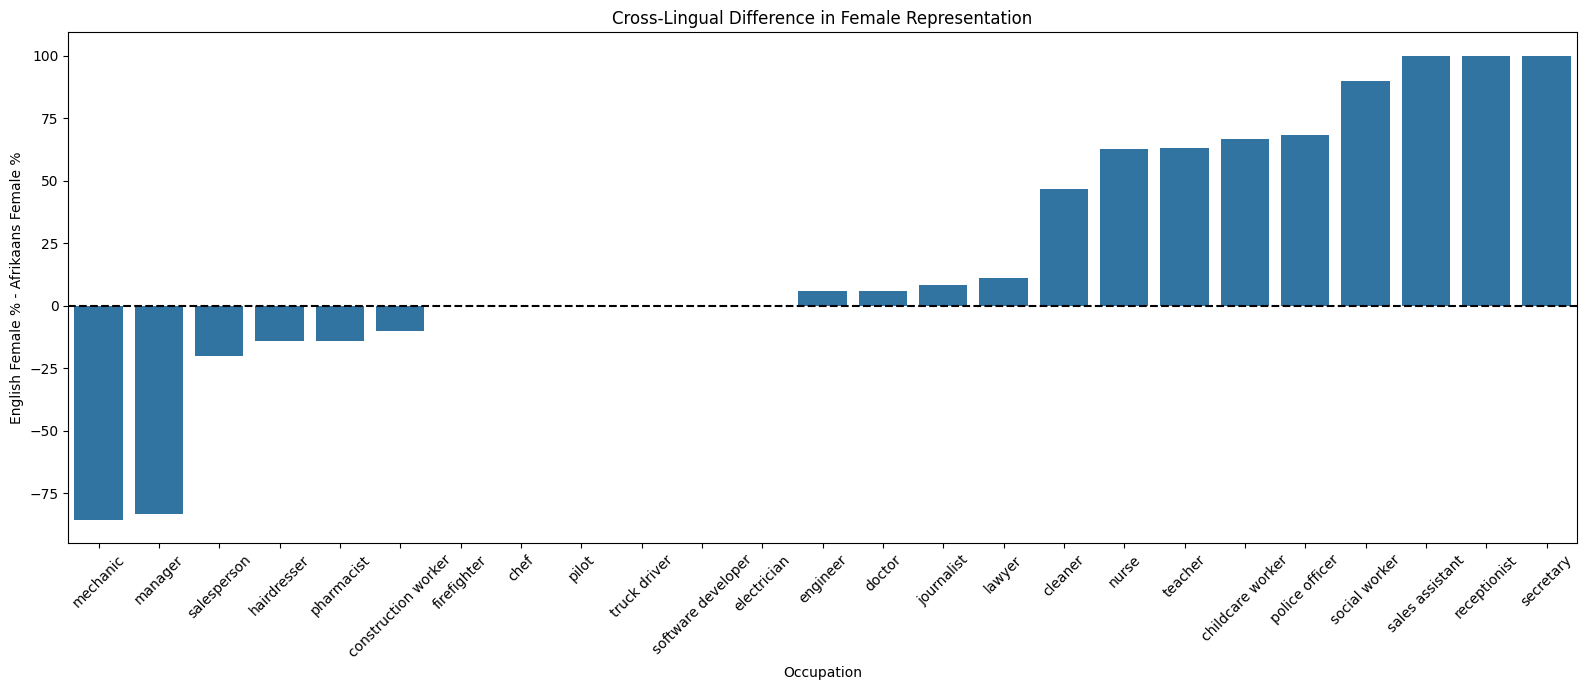

In [115]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=female_cross.sort_values(
        'difference'
    ),
    x='occupation',
    y='difference'
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title(
    "Cross-Lingual Difference in Female Representation"
)

plt.ylabel(
    "English Female % - Afrikaans Female %"
)

plt.xlabel("Occupation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 13. ISCO-08 Category Analysis

In [116]:
analysis_df['isco_category'] = (
    analysis_df['occupation']
    .map(occupation_mapping)
)

analysis_df.head()

,image_id,annotator_1,annotator_2,final_label,language,occupation,isco_category
0,chef_af_01.png,Male,Ambiguous,Male,Afrikaans,chef,Technicians
1,chef_af_02.png,Male,Male,Male,Afrikaans,chef,Technicians
2,chef_af_03.png,Male,Male,Male,Afrikaans,chef,Technicians
3,chef_af_04.png,Male,Male,Male,Afrikaans,chef,Technicians
6,chef_af_07.png,Male,Ambiguous,Male,Afrikaans,chef,Technicians


In [117]:
isco_distribution = pd.crosstab(
    analysis_df['isco_category'],
    analysis_df['final_label'],
    normalize='index'
) * 100

isco_distribution = isco_distribution.reset_index()

isco_distribution

final_label,isco_category,Female,Male
0,Clerks,80.434783,19.565217
1,Craft and related trade,11.764706,88.235294
2,Elementary Occupations,15.555556,84.444444
3,Managers,20.000000,80.000000
4,Plant and Machine Operators,0.000000,100.000000
5,Professionals,31.775701,68.224299
6,Sales and Services,58.518519,41.481481
7,Technicians,0.000000,100.000000


**Stacked Bar Graph**

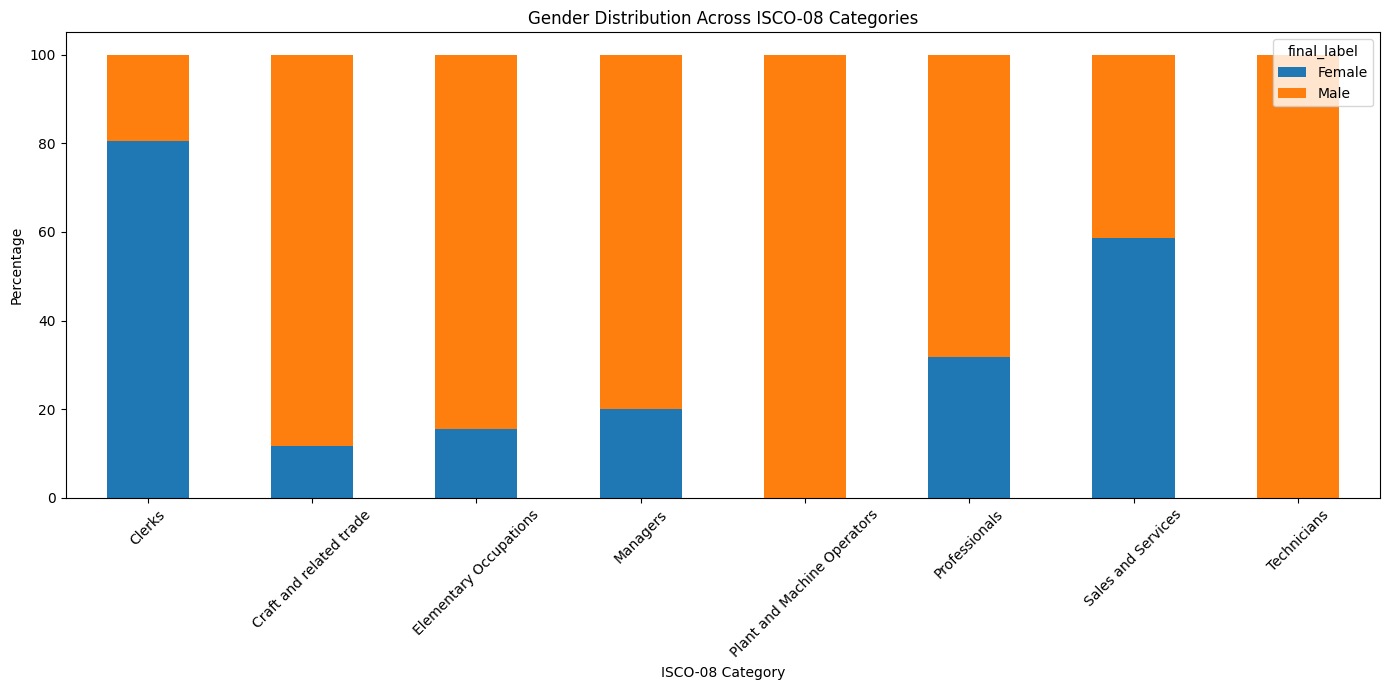

In [118]:
isco_plot = isco_distribution.set_index(
    'isco_category'
)

isco_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title(
    "Gender Distribution Across ISCO-08 Categories"
)

plt.ylabel("Percentage")

plt.xlabel("ISCO-08 Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Heatmap**

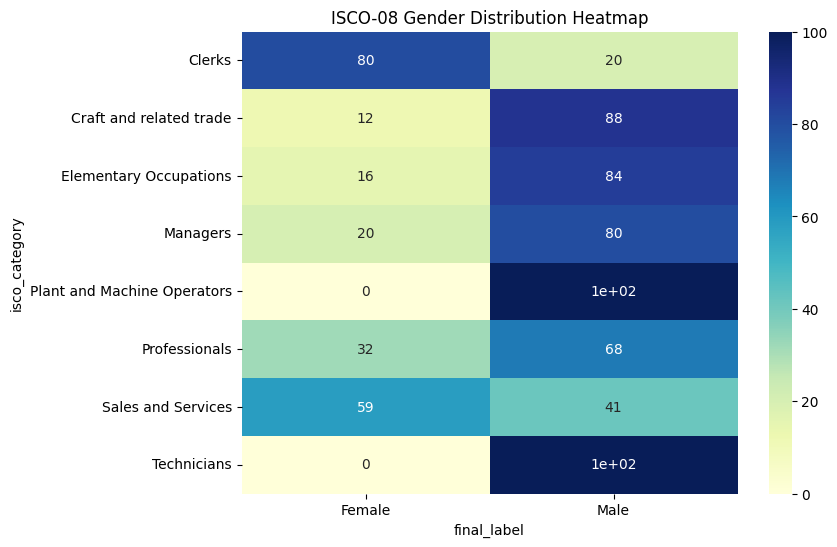

In [119]:
heatmap_isco = isco_plot[
    ['Female', 'Male']
]

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_isco,
    annot=True,
    cmap='YlGnBu'
)

plt.title(
    "ISCO-08 Gender Distribution Heatmap"
)

plt.show()

## 14. Statistical Significance Testing

**1. CHI-SQUARE GOODNESS-OF-FIT TEST**

In [122]:
chi_results = []

for _, row in observed_counts.iterrows():

    occupation = row['occupation']

    male_obs = row.get('Male', 0)
    female_obs = row.get('Female', 0)

    total = male_obs + female_obs

    benchmark_row = benchmark_df[
        benchmark_df['isco_category']
        ==
        occupation_mapping[occupation]
    ]

    expected_male_pct = benchmark_row[
        'expected_male_pct'
    ].values[0]

    expected_female_pct = benchmark_row[
        'expected_female_pct'
    ].values[0]

    expected_male = (
        expected_male_pct / 100
    ) * total

    expected_female = (
        expected_female_pct / 100
    ) * total

    observed = [
        male_obs,
        female_obs
    ]

    expected = np.array([
    expected_male,
    expected_female
    ])

    expected = expected * (
    sum(observed) / expected.sum()
    )

    chi2, p = chisquare(
        f_obs=observed,
        f_exp=expected
    )

    chi_results.append({

        'occupation': occupation,

        'observed_male': male_obs,

        'observed_female': female_obs,

        'expected_male': round(
            expected_male,
            2
        ),

        'expected_female': round(
            expected_female,
            2
        ),

        'chi2': round(chi2,2),

        'p_value': round(p,4)

    })

chi_results_df = pd.DataFrame(
    chi_results
)

chi_results_df.head(25)

,occupation,observed_male,observed_female,expected_male,expected_female,chi2,p_value
0,chef,34,0,16.59,17.41,35.67,0.0000
1,childcare worker,2,12,6.97,7.03,7.06,0.0079
2,cleaner,14,6,12.30,7.70,0.61,0.4347
3,construction worker,24,1,15.38,9.62,12.57,0.0004
4,doctor,25,1,10.97,15.03,31.03,0.0000
5,electrician,25,0,22.00,3.00,3.41,0.0648
6,engineer,29,1,12.66,17.34,36.49,0.0000
7,firefighter,23,0,11.45,11.55,23.18,0.0000
8,hairdresser,6,14,9.96,10.04,3.14,0.0766
9,journalist,16,1,7.17,9.83,18.79,0.0000


In [124]:
chi_results_df['significant'] = np.where(
    chi_results_df['p_value'] < 0.05,
    'Yes',
    'No'
)

chi_results_df.head(25)

,occupation,observed_male,observed_female,expected_male,expected_female,chi2,p_value,significant
0,chef,34,0,16.59,17.41,35.67,0.0000,Yes
1,childcare worker,2,12,6.97,7.03,7.06,0.0079,Yes
2,cleaner,14,6,12.30,7.70,0.61,0.4347,No
3,construction worker,24,1,15.38,9.62,12.57,0.0004,Yes
4,doctor,25,1,10.97,15.03,31.03,0.0000,Yes
5,electrician,25,0,22.00,3.00,3.41,0.0648,No
6,engineer,29,1,12.66,17.34,36.49,0.0000,Yes
7,firefighter,23,0,11.45,11.55,23.18,0.0000,Yes
8,hairdresser,6,14,9.96,10.04,3.14,0.0766,No
9,journalist,16,1,7.17,9.83,18.79,0.0000,Yes


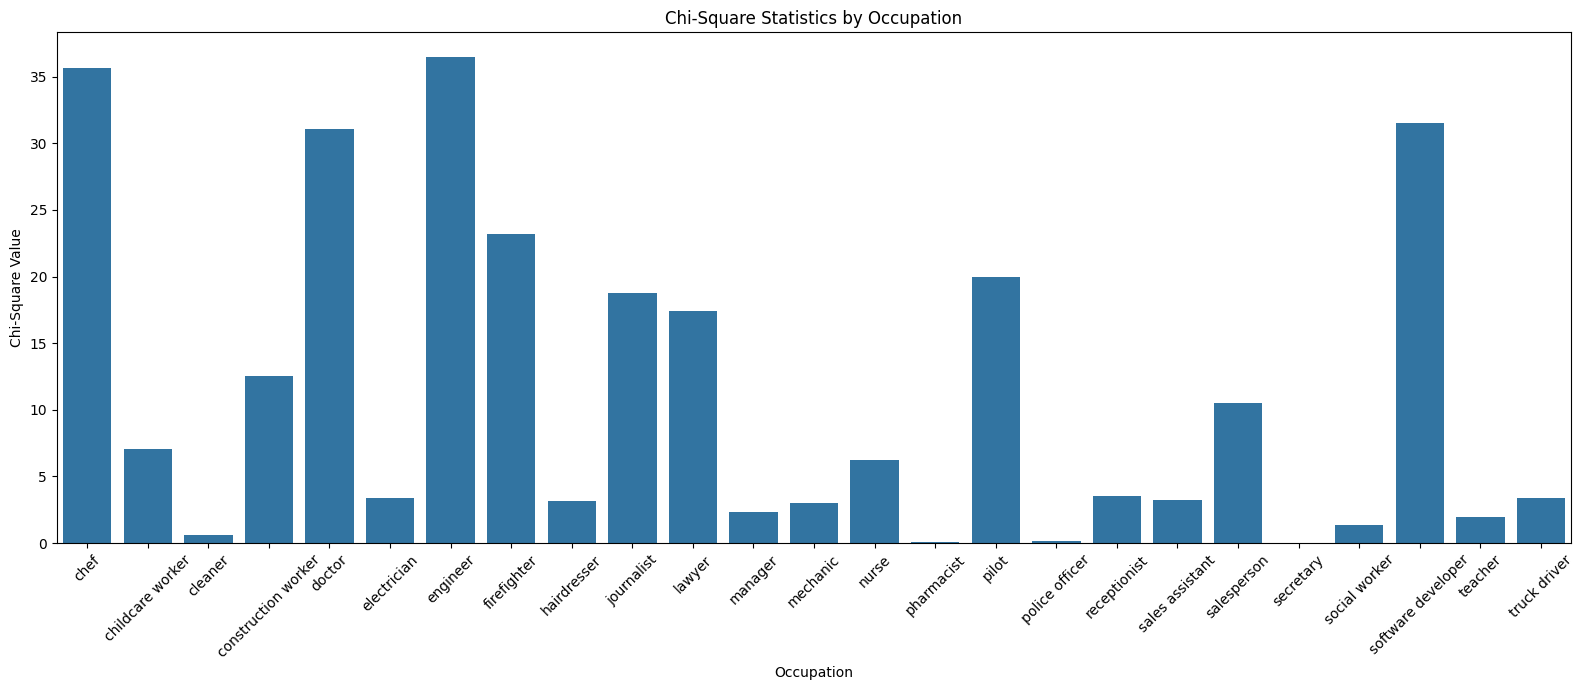

In [125]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=chi_results_df,
    x='occupation',
    y='chi2'
)

plt.title(
    "Chi-Square Statistics by Occupation"
)

plt.ylabel("Chi-Square Value")

plt.xlabel("Occupation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**2. Effect Size Analysis Using Cramér's V**

In [127]:
effect_sizes = []

for occ in analysis_df['occupation'].unique():

    subset = analysis_df[
        analysis_df['occupation'] == occ
    ]

    contingency = pd.crosstab(
        subset['language'],
        subset['final_label']
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency
    )

    n = contingency.sum().sum()

    cramers_v = np.sqrt(
        chi2 /
        (
            n *
            (
                min(contingency.shape) - 1
            )
        )
    )

    effect_sizes.append({

        'occupation': occ,

        'cramers_v': round(
            cramers_v,
            3
        )

    })

effect_df = pd.DataFrame(
    effect_sizes
)

effect_df.head(25)

/tmp/ipykernel_28657/794213492.py:21: RuntimeWarning: invalid value encountered in divide
  chi2 /
/tmp/ipykernel_28657/794213492.py:21: RuntimeWarning: invalid value encountered in divide
  chi2 /
/tmp/ipykernel_28657/794213492.py:21: RuntimeWarning: invalid value encountered in divide
  chi2 /
/tmp/ipykernel_28657/794213492.py:21: RuntimeWarning: invalid value encountered in divide
  chi2 /
/tmp/ipykernel_28657/794213492.py:21: RuntimeWarning: invalid value encountered in divide
  chi2 /
/tmp/ipykernel_28657/794213492.py:21: RuntimeWarning: invalid value encountered in divide
  chi2 /


,occupation,cramers_v
0,chef,NaN
1,childcare worker,0.533
2,cleaner,0.395
3,construction worker,0.042
4,doctor,0.000
5,electrician,NaN
6,engineer,0.000
7,firefighter,NaN
8,hairdresser,0.044
9,journalist,0.000


In [129]:
def interpret_cramers_v(v):

    if v < 0.10:
        return "Negligible"

    elif v < 0.30:
        return "Small"

    elif v < 0.50:
        return "Moderate"

    else:
        return "Strong"

effect_df['interpretation'] = (
    effect_df['cramers_v']
    .apply(interpret_cramers_v)
)

effect_df.head(25)

,occupation,cramers_v,interpretation
0,chef,NaN,Strong
1,childcare worker,0.533,Strong
2,cleaner,0.395,Moderate
3,construction worker,0.042,Negligible
4,doctor,0.000,Negligible
5,electrician,NaN,Strong
6,engineer,0.000,Negligible
7,firefighter,NaN,Strong
8,hairdresser,0.044,Negligible
9,journalist,0.000,Negligible


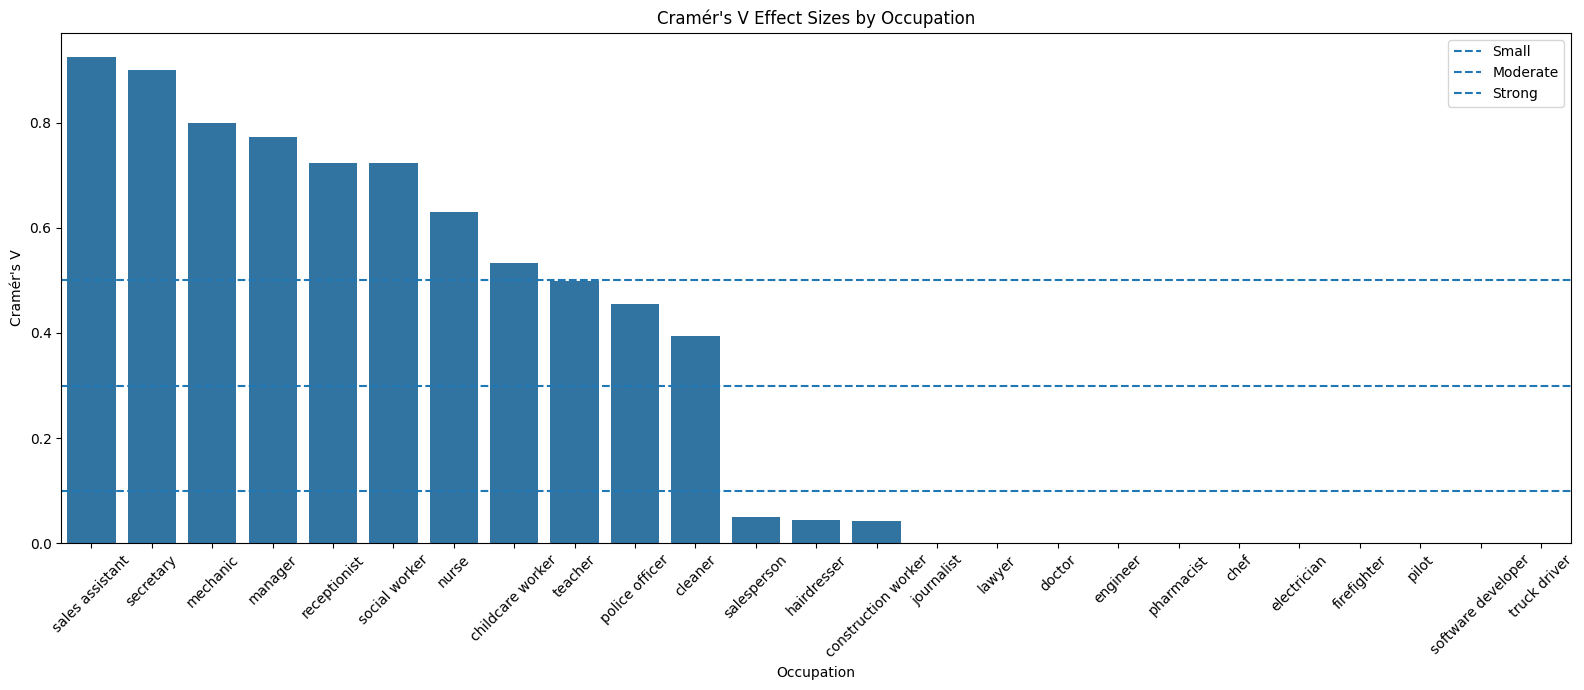

In [130]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=effect_df.sort_values(
        'cramers_v',
        ascending=False
    ),
    x='occupation',
    y='cramers_v'
)

plt.axhline(
    0.10,
    linestyle='--',
    label='Small'
)

plt.axhline(
    0.30,
    linestyle='--',
    label='Moderate'
)

plt.axhline(
    0.50,
    linestyle='--',
    label='Strong'
)

plt.legend()

plt.title(
    "Cramér's V Effect Sizes by Occupation"
)

plt.ylabel("Cramér's V")

plt.xlabel("Occupation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 15. FINAL EXPORTS

In [131]:
agreement_summary.to_csv(
    "agreement_summary.csv",
    index=False
)

kappa_table.to_csv(
    "kappa_results.csv",
    index=False
)

comparison_df.to_csv(
    "comparison_results.csv",
    index=False
)

chi_results_df.to_csv(
    "chi_square_results.csv",
    index=False
)

effect_df.to_csv(
    "effect_sizes.csv",
    index=False
)

female_cross.to_csv(
    "cross_lingual_results.csv",
    index=False
)

isco_distribution.to_csv(
    "isco_distribution.csv",
    index=False
)